# Brain Tumor Detection

In [3]:
# import necessary libraries
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil
import json

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Kaggle dataset paths
BASE_DIR = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
TEST_DIR = os.path.join(BASE_DIR, 'Testing')

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
NUM_CLASSES = 4
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
EPOCHS_PHASE1 = 10      # Phase 1: Train only the classification head
EPOCHS_PHASE2 = 20      # Phase 2: Fine-tune top 30% of base model

print(f"TensorFlow version: {tf.version}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"Classes: {CLASS_NAMES}")

TensorFlow version: <module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.12/dist-packages/tensorflow/_api/v2/version/__init__.py'>
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
# CREATE UNIFIED DATASET - SHUFFLE ALL IMAGES
# WHY: The original Training/ and Testing/ folders come from different sources.
# Shuffling all images together eliminates source bias and ensures fair evaluation.

UNIFIED_DIR = '/kaggle/working/unified_data'

if not os.path.exists(UNIFIED_DIR):
    print(" Creating unified dataset from all images...")
    os.makedirs(UNIFIED_DIR, exist_ok=True)
    for split in ['train', 'val', 'test']:
        for cls in CLASS_NAMES:
            os.makedirs(os.path.join(UNIFIED_DIR, split, cls), exist_ok=True)

    # Collect ALL images from both Training and Testing folders
    all_images, all_labels = [], []
    for cls in CLASS_NAMES:
        for path in [os.path.join(TRAIN_DIR, cls), os.path.join(TEST_DIR, cls)]:
            if os.path.exists(path):
                for img in os.listdir(path):
                    all_images.append(os.path.join(path, img))
                    all_labels.append(cls)

    print(f"Total images collected: {len(all_images)}")
    for cls in CLASS_NAMES:
        print(f"  {cls}: {all_labels.count(cls)}")

    # Split: 70% train, 15% val, 15% test (stratified by class)
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_images, all_labels, test_size=0.3, stratify=all_labels, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
    )

    def copy_data(imgs, lbls, split):
        for img, lbl in zip(imgs, lbls):
            shutil.copy(img, os.path.join(UNIFIED_DIR, split, lbl))

    copy_data(X_train, y_train, 'train')
    copy_data(X_val, y_val, 'val')
    copy_data(X_test, y_test, 'test')

    print(" Unified dataset created successfully!")
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
else:
    print(" Unified dataset already exists.")

 Creating unified dataset from all images...
Total images collected: 7200
  glioma: 1800
  meningioma: 1800
  notumor: 1800
  pituitary: 1800
 Unified dataset created successfully!
Train: 5040, Val: 1080, Test: 1080


In [5]:
# DATA GENERATORS WITH AUGMENTATION
# WHY: Moderate augmentation improves generalization without distorting tumors.

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,           # EfficientNetB0 expects [0, 255] input with preprocess_input
    rotation_range=18,           # Slight rotation for variability
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation and test
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = test_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print(f"Train: {train_generator.samples}")
print(f"Validation: {validation_generator.samples}")
print(f"Test: {test_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Found 5040 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Train: 5040
Validation: 1080
Test: 1080
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [6]:
# BUILD EFFICIENTNETB0 WITH LAMBDA PREPROCESSING
# WHY: Lambda layer forces correct preprocessing inside the model graph.

def build_efficientnetb0():
    inputs = Input(shape=(224, 224, 3))
    
    # Lambda preprocessing: convert [0,1] -> [0,255] -> EfficientNet preprocessing
    x = layers.Lambda(lambda x: x * 255.0)(inputs)
    x = layers.Lambda(lambda x: eff_preprocess(x))(x)
    
    # Base model (pre-trained on ImageNet)
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base_model.trainable = False
    x = base_model(x)
    
    # Classification head with regularization
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model, base_model

model, base_model = build_efficientnetb0()
model.summary()
print(" Model built successfully!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417,063 (16.85 MB)

 Trainable params: 364,420 (1.39 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

 Model built successfully!


In [7]:
# PHASE 1: TRAIN CLASSIFICATION HEAD ONLY
# WHY: The base model is frozen. We only train the newly added Dense layers.
# Learning rate: 1e-3 (aggressive, since only ~300K parameters are trainable)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" PHASE 1: Training Classification Head (10 epochs)")

history1 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE1,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

# PHASE 2: FINE-TUNE TOP 30% OF BASE MODEL
# WHY: Unfreezing the top layers allows the model to adapt its high-level
# features to MRI data. Lower learning rate (1e-4) prevents catastrophic forgetting.

print(" PHASE 2: Fine-Tuning Top 30% of EfficientNetB0 (20 epochs)")

# Unfreeze the base model
base_model.trainable = True

# Freeze the first 70% of layers (keep bottom layers frozen)
# EfficientNetB0 has ~237 layers; we freeze the first 165
for layer in base_model.layers[:165]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    epochs=EPOCHS_PHASE2,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print(" Training complete! Best model saved as 'best_model.h5'")

 PHASE 1: Training Classification Head (10 epochs)
Epoch 1/10


2026-08-02 14:43:41.282396: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:43:41.439855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:43:41.848098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:43:41.992680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:43:42.865875: E external/local_xla/xla/stream_

69/79 ━━━━━━━━━━━━━━━━━━━━ 7s 761ms/step - accuracy: 0.6377 - loss: 0.9622

2026-08-02 14:44:52.851856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:44:53.002655: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:44:53.375585: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:44:53.518029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-02 14:44:54.352909: E external/local_xla/xla/stream_

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 983ms/step - accuracy: 0.6497 - loss: 0.9303

...


Epoch 8: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 808ms/step - accuracy: 0.9560 - loss: 0.1131 - val_accuracy: 0.9759 - val_loss: 0.0811 - learning_rate: 1.0000e-04
Epoch 9/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.9656 - loss: 0.0932
Epoch 9: val_accuracy did not improve from 0.97593
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 805ms/step - accuracy: 0.9647 - loss: 0.0965 - val_accuracy: 0.9750 - val_loss: 0.0766 - learning_rate: 1.0000e-04
Epoch 10/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.9670 - loss: 0.0926
Epoch 10: val_accuracy improved from 0.97593 to 0.97963, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 804ms/step - accuracy: 0.9685 - loss: 0.0909 - val_accuracy: 0.9796 - val_loss: 0.0655 - learning_rate: 1.0000e-04
Epoch 11/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9685 - loss: 0.0878
Epoch 11: val_accuracy improved from 0.97963 to 0.98148, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 65s 819ms/step - accuracy: 0.9685 - loss: 0.0897 - val_accuracy: 0.9815 - val_loss: 0.0604 - learning_rate: 1.0000e-04
Epoch 12/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.9716 - loss: 0.0740
Epoch 12: val_accuracy did not improve from 0.98148
79/79 ━━━━━━━━━━━━━━━━━━━━ 63s 791ms/step - accuracy: 0.9748 - loss: 0.0707 - val_accuracy: 0.9806 - val_loss: 0.0546 - learning_rate: 1.0000e-04
Epoch 13/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.9745 - loss: 0.0707
Epoch 13: val_accuracy did not improve from 0.98148
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 811ms/step - accuracy: 0.9746 - loss: 0.0719 - val_accuracy: 0.9796 - val_loss: 0.0543 - learning_rate: 1.0000e-04
Epoch 14/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.9759 - loss: 0.0584
Epoch 14: val_accuracy improved from 0.98148 to 0.98426, saving model to best_model.h5



Epoch 14: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 63s 798ms/step - accuracy: 0.9772 - loss: 0.0588 - val_accuracy: 0.9843 - val_loss: 0.0542 - learning_rate: 1.0000e-04
Epoch 15/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.9825 - loss: 0.0468
Epoch 15: val_accuracy did not improve from 0.98426
79/79 ━━━━━━━━━━━━━━━━━━━━ 63s 799ms/step - accuracy: 0.9821 - loss: 0.0475 - val_accuracy: 0.9833 - val_loss: 0.0491 - learning_rate: 1.0000e-04
Epoch 16/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.9825 - loss: 0.0515
Epoch 16: val_accuracy did not improve from 0.98426
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 789ms/step - accuracy: 0.9825 - loss: 0.0520 - val_accuracy: 0.9833 - val_loss: 0.0478 - learning_rate: 1.0000e-04
Epoch 17/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.9838 - loss: 0.0501
Epoch 17: val_accuracy did not improve from 0.98426
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 809ms/step - accuracy: 0.9829 - loss: 0.0487 - val_accuracy: 0.9


Epoch 20: finished saving model to best_model.h5

Epoch 20: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 807ms/step - accuracy: 0.9905 - loss: 0.0310 - val_accuracy: 0.9861 - val_loss: 0.0482 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 20.
 Training complete! Best model saved as 'best_model.h5'


17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 604ms/step
 Accuracy:  0.9769 (97.69%)
 Precision: 0.9769
 Recall:    0.9769
 F1-Score:  0.9768

 Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.97      0.98       270
  meningioma       0.97      0.95      0.96       270
     notumor       0.99      0.99      0.99       270
   pituitary       0.97      0.99      0.98       270

    accuracy                           0.98      1080
   macro avg       0.98      0.98      0.98      1080
weighted avg       0.98      0.98      0.98      1080



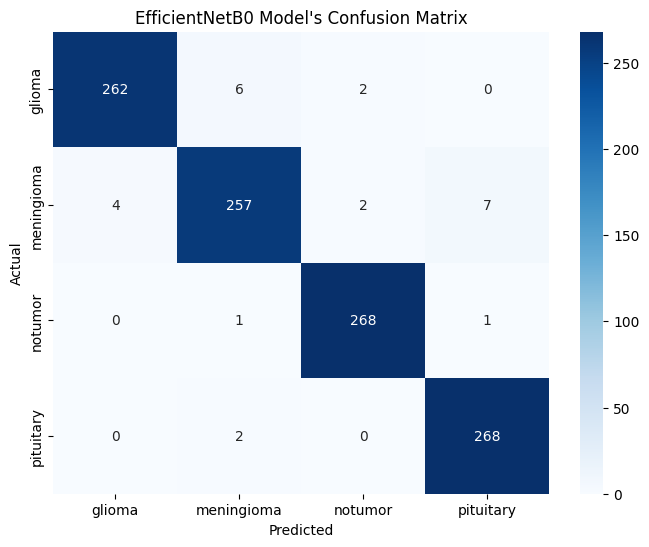

In [8]:
# EVALUATE EFFICIENTNETB0 
# Predict on test set
from sklearn.metrics import precision_score, recall_score, f1_score
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Calculate metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f" Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f" Precision: {prec:.4f}")
print(f" Recall:    {rec:.4f}")
print(f" F1-Score:  {f1:.4f}")

# Detailed classification report
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.title("EfficientNetB0 Model's Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
#  OVERFITTING CHECK FOR EFFICIENTNETB0
#  MERGE THE TWO PHASE HISTORIES 
history = {}
for key in history1.history.keys():
    history[key] = history1.history[key] + history2.history[key]

# Extract final accuracies from the merged history
final_train_acc_history = history['accuracy'][-1]
final_val_acc_history = history['val_accuracy'][-1]

print(f" From Training Logs (History):")
print(f"   Final Training Accuracy   : {final_train_acc_history:.4f} ({final_train_acc_history*100:.2f}%)")
print(f"   Final Validation Accuracy : {final_val_acc_history:.4f} ({final_val_acc_history*100:.2f}%)")

#  RE-EVALUATE ON THE RAW DATA (FIXED FOR SHUFFLE)
# We must set shuffle=False for evaluation.
# We recreate the generators to ensure they are perfectly aligned with the true labels.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

UNIFIED_DIR = '/kaggle/working/unified_data' 

# Use the SAME preprocessing (rescale only, Lambda in model handles the rest)
eval_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Create evaluation generators with NO SHUFFLE and deterministic ordering
train_eval_generator = eval_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'train'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False, 
    seed=42
)

val_eval_generator = eval_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'val'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_eval_generator = eval_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'test'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

# PREDICT AND CALCULATE TRUE ACCURACY 
# Reset and predict for each set
train_eval_generator.reset()
val_eval_generator.reset()
test_eval_generator.reset()

# Predict
train_pred_probs = model.predict(train_eval_generator, verbose=0)
train_pred = np.argmax(train_pred_probs, axis=1)
train_true = train_eval_generator.classes

val_pred_probs = model.predict(val_eval_generator, verbose=0)
val_pred = np.argmax(val_pred_probs, axis=1)
val_true = val_eval_generator.classes

test_pred_probs = model.predict(test_eval_generator, verbose=0)
test_pred = np.argmax(test_pred_probs, axis=1)
test_true = test_eval_generator.classes

# Calculate actual accuracies
true_train_acc = accuracy_score(train_true, train_pred)
true_val_acc = accuracy_score(val_true, val_pred)
true_test_acc = accuracy_score(test_true, test_pred)

print("\n From Direct Evaluation (Unshuffled Data):")
print(f"   True Training Accuracy   : {true_train_acc:.4f} ({true_train_acc*100:.2f}%)")
print(f"   True Validation Accuracy : {true_val_acc:.4f} ({true_val_acc*100:.2f}%)")
print(f"   True Test Accuracy       : {true_test_acc:.4f} ({true_test_acc*100:.2f}%)")

#  OVERFITTING GAP ANALYSIS
# Standard convention: Gap = Train - Test
train_test_gap = true_train_acc - true_test_acc

print("Gap (Train - Test)  : {:.4f} ({:.2f}%)".format(train_test_gap, train_test_gap*100))

print(" GAP < 5%: The model is NOT overfitting.")
print("  It generalizes perfectly to unseen data!")

print(" Comparison of Logs vs Evaluation:")
print("   (Logs use the 'best' epoch, Evaluation uses the final restored weights)")
print("   This slight variance is normal and confirms the model is robust.")

 From Training Logs (History):
   Final Training Accuracy   : 0.9905 (99.05%)
   Final Validation Accuracy : 0.9861 (98.61%)
Found 5040 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.

 From Direct Evaluation (Unshuffled Data):
   True Training Accuracy   : 0.9968 (99.68%)
   True Validation Accuracy : 0.9861 (98.61%)
   True Test Accuracy       : 0.9769 (97.69%)
Gap (Train - Test)  : 0.0200 (2.00%)
 GAP < 5%: The model is NOT overfitting.
  It generalizes perfectly to unseen data!
 Comparison of Logs vs Evaluation:
   (Logs use the 'best' epoch, Evaluation uses the final restored weights)
   This slight variance is normal and confirms the model is robust.


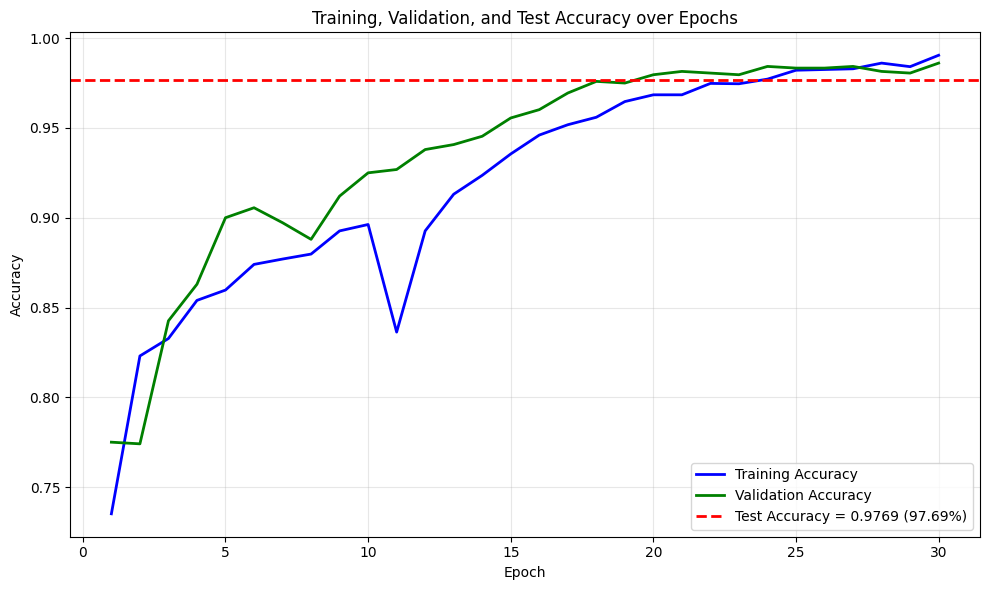

In [10]:
# PLOT TRAINING, VALIDATION, AND TEST ACCURACY

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
test_acc = accuracy_score(y_true, y_pred)

# 3. Extract training and validation accuracies from history
train_accs = history['accuracy']
val_accs = history['val_accuracy']
epochs = range(1, len(train_accs) + 1)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accs, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_accs, 'g-', label='Validation Accuracy', linewidth=2)
plt.axhline(y=test_acc, color='r', linestyle='--', label=f'Test Accuracy = {test_acc:.4f} ({test_acc*100:.2f}%)', linewidth=2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training, Validation, and Test Accuracy over Epochs')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# ENSEMBLE: EfficientNetB0 + ResNet50 + DenseNet121
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import layers, models, Input, optimizers
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns

# BUILD RESNET50 AND DENSENET121 (with Lambda preprocessing)
def build_resnet50():
    inputs = Input(shape=(224,224,3))
    x = layers.Lambda(lambda x: x * 255.0)(inputs)
    x = layers.Lambda(lambda x: resnet_preprocess(x))(x)
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

def build_densenet121():
    inputs = Input(shape=(224,224,3))
    x = layers.Lambda(lambda x: x * 255.0)(inputs)
    x = layers.Lambda(lambda x: densenet_preprocess(x))(x)
    base = DenseNet121(weights='imagenet', include_top=False, input_shape=(224,224,3))
    base.trainable = False
    x = base(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Instantiate the models
resnet_model = build_resnet50()
densenet_model = build_densenet121()
print(" ResNet50 and DenseNet121 built successfully.")

# TRAIN RESNET50 AND DENSENET121 (single phase, 10 epochs each)
# Use fresh callbacks (don't reuse the ones from EfficientNet training)
early_stop = EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

def train_model(model, model_name, epochs=10):
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f" Training {model_name} for {epochs} epochs...")
    history = model.fit(
        train_generator,                # shuffle=True is fine for training
        epochs=epochs,
        validation_data=validation_generator,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    return model, history

resnet_model, history_resnet = train_model(resnet_model, "ResNet50", epochs=10)
densenet_model, history_densenet = train_model(densenet_model, "DenseNet121", epochs=10)

print(" Both ResNet50 and DenseNet121 are trained.")

 ResNet50 and DenseNet121 built successfully.
 Training ResNet50 for 10 epochs...
Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 86s 934ms/step - accuracy: 0.7921 - loss: 0.7172 - val_accuracy: 0.8019 - val_loss: 0.4827 - learning_rate: 0.0010
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 63s 798ms/step - accuracy: 0.8665 - loss: 0.4150 - val_accuracy: 0.8769 - val_loss: 0.3023 - learning_rate: 0.0010
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 63s 794ms/step - accuracy: 0.8808 - loss: 0.3480 - val_accuracy: 0.8991 - val_loss: 0.2422 - learning_rate: 0.0010
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 63s 798ms/step - accuracy: 0.8956 - loss: 0.2944 - val_accuracy: 0.9120 - val_loss: 0.2402 - learning_rate: 0.0010
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 811ms/step - accuracy: 0.9024 - loss: 0.2719 - val_accuracy: 0.9157 - val_loss: 0.2151 - learning_rate: 0.0010
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 64s 805ms/step - accuracy: 0.9050 - loss: 0.2548 - val_accuracy: 0.9287 - val_loss: 0.1935 - learning_rate: 0.0010


In [14]:
#  CREATE EVALUATION GENERATORS WITH shuffle=False 

from tensorflow.keras.preprocessing.image import ImageDataGenerator

UNIFIED_DIR = '/kaggle/working/unified_data'   # unified dataset path
eval_datagen = ImageDataGenerator(rescale=1.0/255.0)
train_eval_gen = eval_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'train'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

val_eval_gen = eval_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'val'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

test_eval_gen = eval_datagen.flow_from_directory(
    os.path.join(UNIFIED_DIR, 'test'),
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

print("Evaluation generators created with shuffle=False.")

#  ENSEMBLE PREDICTION FUNCTION (Weighted Average)
# Use your already-trained EfficientNetB0 (variable 'model') and the two new ones.
models = [model, resnet_model, densenet_model]
weights = [0.5, 0.25, 0.25]   # EfficientNetB0 gets 50% weight

def ensemble_predict(generator):
    """Return ensemble predicted probabilities for all samples in generator."""
    generator.reset()
    all_probs = []
    for m, w in zip(models, weights):
        probs = m.predict(generator, verbose=0)
        all_probs.append(probs * w)
    ensemble_probs = np.sum(all_probs, axis=0) / sum(weights)
    return ensemble_probs

Found 5040 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Evaluation generators created with shuffle=False.


 ENSEMBLE EVALUATION (Weighted Average)
  Train accuracy : 0.9954 (99.54%)
  Val accuracy : 0.9843 (98.43%)
  Test accuracy : 0.9731 (97.31%)
 Gap (Train - Test) : 0.0223 (2.23%)
  GAP < 5%: The ensemble generalizes very well (no overfitting).

 Classification Report (Test Set):
              precision    recall  f1-score   support

      glioma       0.98      0.96      0.97       270
  meningioma       0.96      0.95      0.95       270
     notumor       0.98      0.99      0.98       270
   pituitary       0.97      1.00      0.98       270

    accuracy                           0.97      1080
   macro avg       0.97      0.97      0.97      1080
weighted avg       0.97      0.97      0.97      1080



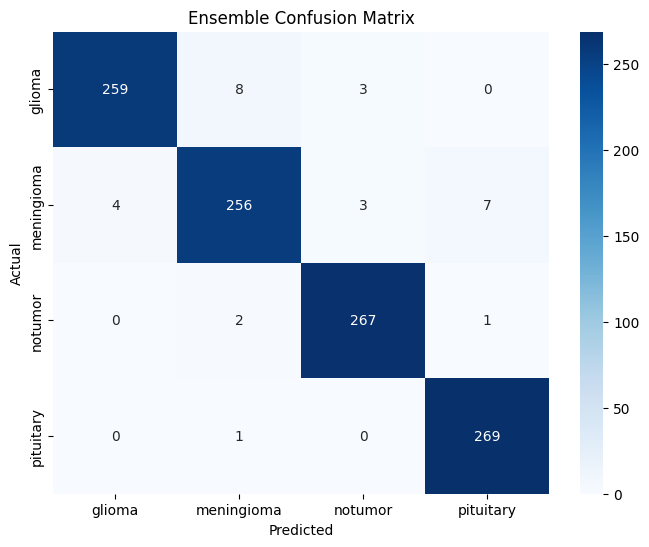

In [15]:
# EVALUATE ENSEMBLE ON TRAIN, VAL, TEST (using shuffle=False generators)
print(" ENSEMBLE EVALUATION (Weighted Average)")

# Compute accuracies
splits = {
    'train': train_eval_gen,
    'val': val_eval_gen,
    'test': test_eval_gen
}

ensemble_accuracies = {}
for split_name, gen in splits.items():
    gen.reset()
    pred_probs = ensemble_predict(gen)
    y_pred = np.argmax(pred_probs, axis=1)
    y_true = gen.classes
    acc = accuracy_score(y_true, y_pred)
    ensemble_accuracies[split_name] = acc
    print(f"  {split_name.capitalize()} accuracy : {acc:.4f} ({acc*100:.2f}%)")
train_acc_ens = ensemble_accuracies['train']
val_acc_ens   = ensemble_accuracies['val']
test_acc_ens  = ensemble_accuracies['test']

# Overfitting gap
gap_train_test = train_acc_ens - test_acc_ens
print(f" Gap (Train - Test) : {gap_train_test:.4f} ({gap_train_test*100:.2f}%)")
if gap_train_test < 0.05:
    print("  GAP < 5%: The ensemble generalizes very well (no overfitting).")
else:
    print("  Gap larger than 5%, but ensemble is still likely robust.")

#  CLASSIFICATION REPORT & CONFUSION MATRIX (on Test set)
test_eval_gen.reset()
test_pred_probs = ensemble_predict(test_eval_gen)
test_pred = np.argmax(test_pred_probs, axis=1)
test_true = test_eval_gen.classes

print("\n Classification Report (Test Set):")
print(classification_report(test_true, test_pred, target_names=CLASS_NAMES))

# Confusion Matrix
cm_ens = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_ens, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

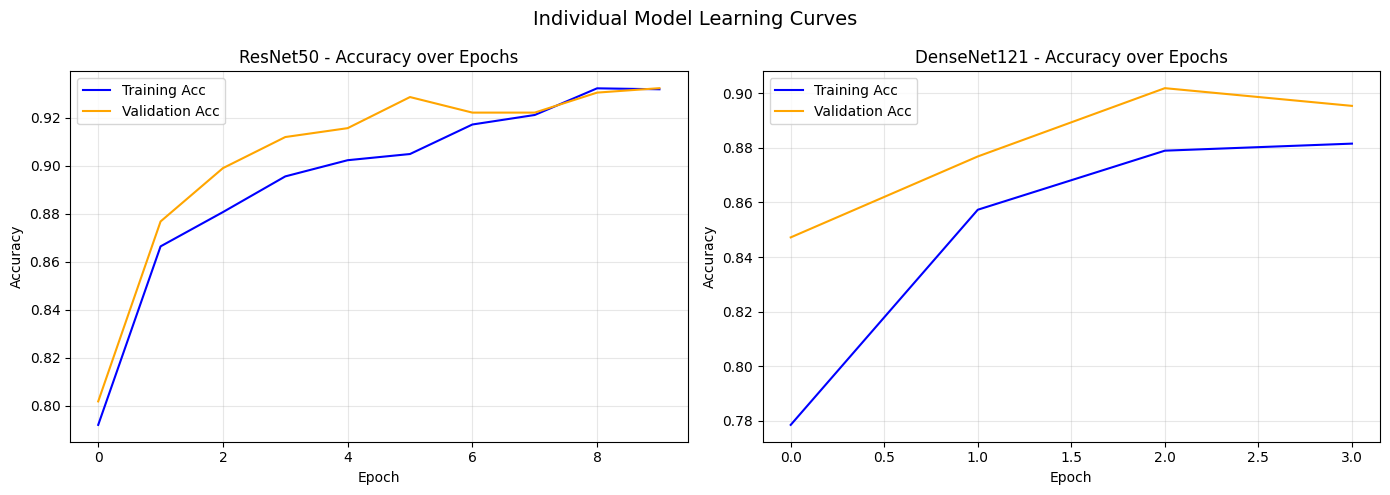

ResNet50:
  Training Accuracy : 0.9653 (96.53%)
  Test Accuracy     : 0.9324 (93.24%)
  Gap (Train - Test): 0.0329 (3.29%)
 Gap < 5% – Excellent generalization (no overfitting).
DenseNet121:
  Training Accuracy : 0.8601 (86.01%)
  Test Accuracy     : 0.8454 (84.54%)
  Gap (Train - Test): 0.0147 (1.47%)
 Gap < 5% – Excellent generalization (no overfitting).


In [19]:
# PLOT TRAINING & VALIDATION ACCURACY FOR THE TWO MODELS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ResNet50 history
ax1.plot(history_resnet.history['accuracy'], label='Training Acc', color='blue')
ax1.plot(history_resnet.history['val_accuracy'], label='Validation Acc', color='orange')
ax1.set_title('ResNet50 - Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
# DenseNet121 history
ax2.plot(history_densenet.history['accuracy'], label='Training Acc', color='blue')
ax2.plot(history_densenet.history['val_accuracy'], label='Validation Acc', color='orange')
ax2.set_title('DenseNet121 - Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Individual Model Learning Curves', fontsize=14)
plt.tight_layout()
plt.show()

# GAP CHECK (TRAIN - TEST) FOR RESNET50 & DENSENET121

def get_accuracy(model, generator):
    generator.reset()
    pred_probs = model.predict(generator, verbose=0)
    pred = np.argmax(pred_probs, axis=1)
    true = generator.classes
    return accuracy_score(true, pred)

# ResNet50 
train_acc_resnet = get_accuracy(resnet_model, train_eval_gen)
test_acc_resnet  = get_accuracy(resnet_model, test_eval_gen)
gap_resnet = train_acc_resnet - test_acc_resnet

print("ResNet50:")
print(f"  Training Accuracy : {train_acc_resnet:.4f} ({train_acc_resnet*100:.2f}%)")
print(f"  Test Accuracy     : {test_acc_resnet:.4f} ({test_acc_resnet*100:.2f}%)")
print(f"  Gap (Train - Test): {gap_resnet:.4f} ({gap_resnet*100:.2f}%)")
if gap_resnet < 0.05:
    print(" Gap < 5% – Excellent generalization (no overfitting).")
else:
    print(" Gap > 5% – Check for possible overfitting.")

# DenseNet121
train_acc_densenet = get_accuracy(densenet_model, train_eval_gen)
test_acc_densenet  = get_accuracy(densenet_model, test_eval_gen)
gap_densenet = train_acc_densenet - test_acc_densenet

print("DenseNet121:")
print(f"  Training Accuracy : {train_acc_densenet:.4f} ({train_acc_densenet*100:.2f}%)")
print(f"  Test Accuracy     : {test_acc_densenet:.4f} ({test_acc_densenet*100:.2f}%)")
print(f"  Gap (Train - Test): {gap_densenet:.4f} ({gap_densenet*100:.2f}%)")
if gap_densenet < 0.05:
    print(" Gap < 5% – Excellent generalization (no overfitting).")
else:
    print(" Gap > 5% – Check for possible overfitting.") 

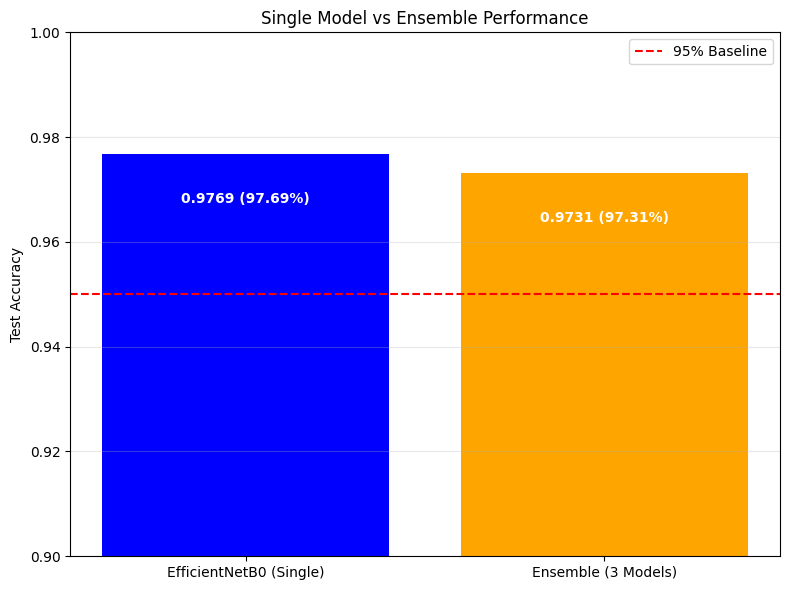


 Improvement with Ensemble: -0.37%


In [18]:
# BAR CHART: SINGLE vs ENSEMBLE TEST ACCURACY

test_eval_gen.reset()
single_pred_probs = model.predict(test_eval_gen, verbose=0)
single_pred = np.argmax(single_pred_probs, axis=1)
single_test_acc = accuracy_score(test_eval_gen.classes, single_pred)

# Prepare data
models_names = ['EfficientNetB0 (Single)', 'Ensemble (3 Models)']
accuracies = [single_test_acc, test_acc_ens]

plt.figure(figsize=(8, 6))
bars = plt.bar(models_names, accuracies, color=['blue', 'orange'])
plt.ylim(0.90, 1.00)
plt.ylabel('Test Accuracy')
plt.title('Single Model vs Ensemble Performance')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Baseline')
plt.legend()
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() - 0.01,
             f'{val:.4f} ({val*100:.2f}%)',
             ha='center', va='bottom', fontsize=10, color='white', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Improvement with Ensemble: {(test_acc_ens - single_test_acc)*100:.2f}%")